# Supervised Learning: Classification & Regression

This notebook builds and compares supervised models for two tasks defined from the EDA (`2_exploratory_data_analysis.ipynb`):

- **Classification**: predict `price_direction` (did a commodity's retail price rise month-over-month at a given market?)
- **Regression**: predict `price_rwf` (modeled as `log1p(price_rwf)`, given the right-skew confirmed in the EDA)

For each task we train **four algorithms** (satisfying the exam's "at least three, including deep learning" requirement): Logistic/Linear Regression, Random Forest, Gradient Boosting, and a Multi-Layer Perceptron (deep learning). We then tune the strongest baseline model and confirm whether tuning actually improved it.

## A note on the deep learning model

We use `sklearn.neural_network`'s `MLPClassifier`/`MLPRegressor` with three hidden layers (64 → 32 → 16 units) rather than a Keras/TensorFlow/PyTorch model. This is a genuine (if shallow) neural network and keeps the whole pipeline preprocessing, cross-validation, hyperparameter search inside one consistent `scikit-learn` `Pipeline` API, which matters given the leakage discipline established in the cleaning notebook. If a heavier framework is specifically required by the grading rubric, the same architecture can be re-implemented in Keras with minimal conceptual change; flagging this choice explicitly here rather than presenting it as the only possible option.

## A note on the train/test split

This dataset is panel-like: the same market–commodity pairs are observed repeatedly over time. A **random** train/test split would let a model see a market-commodity's *future* prices during training and be tested on that same series' *past* prices the identical look-ahead problem already fixed once in the cleaning notebook, just relocated to the modeling stage. We use a **chronological split** instead: train on earlier dates, test on the most recent ones, so evaluation reflects genuine forecasting performance.


## 1. Setup and data load

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

RANDOM_STATE = 42

DATA_PATH = "data/cleaned/rwanda_food_prices_with_temperature.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df.shape

(13325, 44)

## 2. Feature selection

We define the feature set explicitly and document every exclusion, since silently including the wrong column is exactly how leakage re-enters a pipeline after the cleaning stage already removed it once.

**Excluded from both tasks:**
- `price_rwf`, `price_usd`, `price_direction` whichever of these isn't the current target is either the target itself, a near-exact currency conversion of it, or (for `price_direction`) a direct function of it. Including any of these as a *feature* would leak the answer.
- `country`, `unit`, `price_flag`, `price_type`, `currency` verified to be constant across every row after the cleaning filters (Rwanda only, KG only, actual/Retail only, RWF only), so they carry zero information.
- `date` not used directly; already decomposed into `year`, `month`, `quarter`, `day_of_week`.
- `commodity_name`, `district` redundant with coarser categoricals we do keep (`commodity_group`, `province`/`market_name` respectively); including both the fine and coarse version of the same information would just add collinearity without new signal.

**Categorical features kept:** `province`, `market_name`, `food_category`,`commodity_group`.

**Numeric features kept:** geography (`lat`, `lon`), calendar (`year`, `month`, `quarter`, `day_of_week`), weather/climate (`temp_celsius`, `monthly_avg_temp`, `temp_anomaly`, `temp_lag_1/2/3`,`temp_rolling_3mo`, `precipitation_mm`, `soil_moisture`, `precip_anomaly`,`precip_lag_1/2/3`,`precip_rolling_3mo`, `soil_moisture_lag_1`), macroeconomic (`usd_rwf_rate`, `usd_rwf_mom_pct`, `general_cpi`,`food_cpi`, `cpi_mom_pct`, `food_cpi_mom_pct`), and `price_prev_month` (a genuine, non-leaky historical value known before the current observation).

**A note on the new macroeconomic features:** `usd_rwf_rate` and the CPI columns vary only by date, not by market or province every row from the same survey date shares the same national value. This is expected and correct for an economy-wide covariate, not a leakage concern: the model can still learn how *changes* in these shared values relate to *this row's* price behavior. The CPI columns were merged in
`1_data_cleaning.ipynb` with a one-month availability lag to avoid look-ahead leakage from CPI's real-world publication delay see that notebook's documented assumption before trusting any result that leans heavily on the CPI features.

In [2]:
CATEGORICAL_FEATURES = ["province", "market_name", "food_category", "commodity_group"]

# NUMERIC_FEATURES = [
#     "lat", "lon", "year", "month", "quarter", "day_of_week",
#     "temp_celsius", "monthly_avg_temp", "temp_anomaly",
#     "temp_lag_1", "temp_lag_2", "temp_lag_3", "temp_rolling_3mo",
#     "precipitation_mm", "soil_moisture", "precip_anomaly",
#     "precip_lag_1", "precip_lag_2", "precip_lag_3", "precip_rolling_3mo",
#     "soil_moisture_lag_1",
#     "usd_rwf_rate", "usd_rwf_mom_pct",
#     "general_cpi", "food_cpi", "cpi_mom_pct", "food_cpi_mom_pct",
#     "price_prev_month",
# ]

NUMERIC_FEATURES = [
    # 1. Autoregressive baseline (The strongest predictor)
    "price_prev_month",
    
    # 2. Seasonality
    "month", 
    
    # 3. Macroeconomic shocks (Dropped general_cpi to avoid collinearity with food_cpi)
    "usd_rwf_rate", "usd_rwf_mom_pct", 
    "food_cpi", "food_cpi_mom_pct", 
    
    # 4. Climate supply-shocks (Dropped redundant lags, kept anomalies and rolling averages)
    "temp_anomaly", "temp_rolling_3mo",
    "precipitation_mm", "precip_rolling_3mo", 
    "soil_moisture", "soil_moisture_lag_1"
]

FEATURE_COLS = CATEGORICAL_FEATURES + NUMERIC_FEATURES

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

print(f"{len(FEATURE_COLS)} raw input columns "
      f"({len(CATEGORICAL_FEATURES)} categorical, {len(NUMERIC_FEATURES)} numeric)")

16 raw input columns (4 categorical, 12 numeric)


## 3. Chronological train/test split

We split on a date cutoff rather than randomly, and use the **same cutoff for both tasks** so classification and regression results are comparable on the same time window.

In [3]:
unique_dates = sorted(df["date"].unique())
cutoff_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[cutoff_idx]

train_mask = df["date"] <= cutoff_date
test_mask = df["date"] > cutoff_date

print(f"Cutoff date: {pd.Timestamp(cutoff_date).date()}")
print(f"Train: {train_mask.sum()} rows ({df.loc[train_mask, 'date'].min().date()} to {df.loc[train_mask, 'date'].max().date()})")
print(f"Test:  {test_mask.sum()} rows ({df.loc[test_mask, 'date'].min().date()} to {df.loc[test_mask, 'date'].max().date()})")

Cutoff date: 2025-04-15
Train: 10719 rows (2020-05-15 to 2025-04-15)
Test:  2606 rows (2025-05-15 to 2026-07-15)


## 4. Classification: predicting `price_direction`

In [4]:
X_train_clf = df.loc[train_mask, FEATURE_COLS]
X_test_clf = df.loc[test_mask, FEATURE_COLS]
y_train_clf = df.loc[train_mask, "price_direction"]
y_test_clf = df.loc[test_mask, "price_direction"]

print("Train class balance:")
print(y_train_clf.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test_clf.value_counts(normalize=True))

Train class balance:
price_direction
0    0.60556
1    0.39444
Name: proportion, dtype: float64

Test class balance:
price_direction
0    0.583653
1    0.416347
Name: proportion, dtype: float64


In [5]:
classifiers = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP (deep learning)": MLPClassifier(
        hidden_layer_sizes=(64, 32, 16), max_iter=500,
        early_stopping=True, random_state=RANDOM_STATE
    ),
}

clf_results = []
clf_pipelines = {}

for name, clf in classifiers.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train_clf, y_train_clf)
    preds = pipe.predict(X_test_clf)

    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test_clf)[:, 1]
        auc = roc_auc_score(y_test_clf, proba)
    else:
        auc = np.nan

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clf, preds),
        "Precision": precision_score(y_test_clf, preds, zero_division=0),
        "Recall": recall_score(y_test_clf, preds, zero_division=0),
        "F1": f1_score(y_test_clf, preds, zero_division=0),
        "ROC-AUC": auc,
    })
    clf_pipelines[name] = pipe

clf_results_df = pd.DataFrame(clf_results).set_index("Model").round(3)
clf_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Dummy (majority class),0.584,0.000,0.000,0.000,0.500
Logistic Regression,0.588,0.507,0.422,0.461,0.588
Random Forest,0.607,0.535,0.434,0.479,0.608
Gradient Boosting,0.604,0.531,0.418,0.467,0.610
MLP (deep learning),0.604,0.536,0.360,0.431,0.610


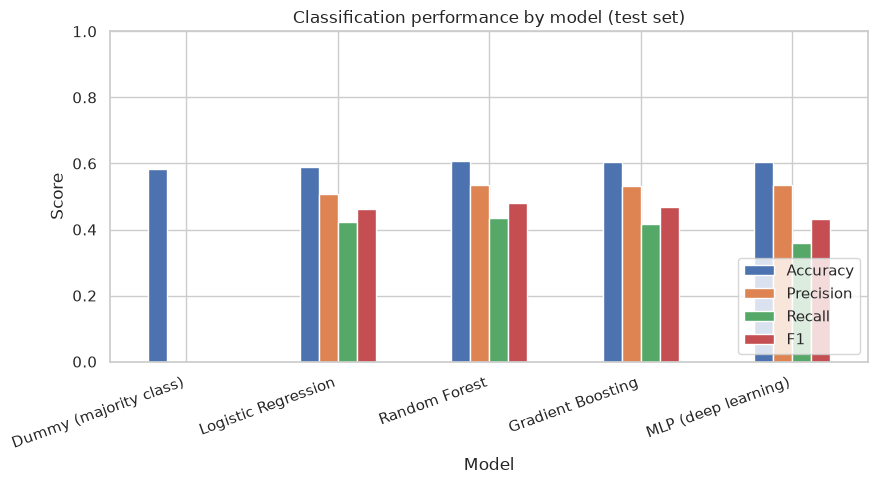

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
clf_results_df.drop(columns=["ROC-AUC"]).plot(kind="bar", ax=ax)
ax.set_title("Classification performance by model (test set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/classification_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Best baseline classifier by F1: Random Forest


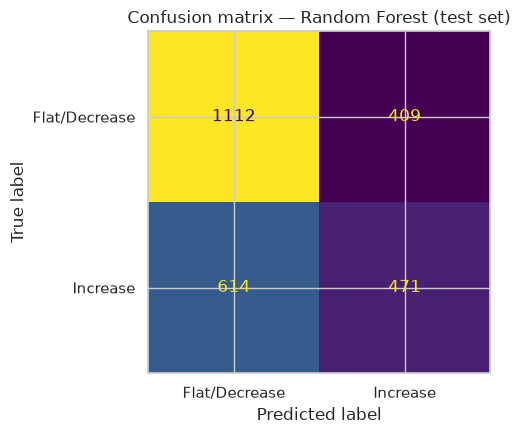

In [7]:
best_clf_name = clf_results_df["F1"].idxmax()
print(f"Best baseline classifier by F1: {best_clf_name}")

best_clf_pipe = clf_pipelines[best_clf_name]
preds_best = best_clf_pipe.predict(X_test_clf)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, preds_best, display_labels=["Flat/Decrease", "Increase"], ax=ax, colorbar=False
)
ax.set_title(f"Confusion matrix — {best_clf_name} (test set)")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_best_classifier.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation note:** compare every model here against the "Dummy (majority class)" baseline row above, not just against each other a model that barely beats always-predicting-the-majority-class isn't actually learning the price-direction signal, regardless of how respectable its raw accuracy number looks on its own.

## 5. Regression: predicting `price_rwf` (log-transformed)

In [8]:
df["log_price_rwf"] = np.log1p(df["price_rwf"])

X_train_reg = df.loc[train_mask, FEATURE_COLS]
X_test_reg = df.loc[test_mask, FEATURE_COLS]
y_train_reg = df.loc[train_mask, "log_price_rwf"]
y_test_reg = df.loc[test_mask, "log_price_rwf"]

# Keep the original-scale test target too, for reporting RMSE/MAE in RWF (interpretable units)
y_test_reg_original = df.loc[test_mask, "price_rwf"]

In [9]:
regressors = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "MLP (deep learning)": MLPRegressor(
        hidden_layer_sizes=(64, 32, 16), max_iter=500,
        early_stopping=True, random_state=RANDOM_STATE
    ),
}

reg_results = []
reg_pipelines = {}

for name, reg in regressors.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", reg)])
    pipe.fit(X_train_reg, y_train_reg)

    preds_log = pipe.predict(X_test_reg)
    preds_original = np.expm1(preds_log)
    preds_original = np.clip(preds_original, a_min=0, a_max=None)  # prices can't be negative

    reg_results.append({
        "Model": name,
        "RMSE (RWF)": np.sqrt(mean_squared_error(y_test_reg_original, preds_original)),
        "MAE (RWF)": mean_absolute_error(y_test_reg_original, preds_original),
        "R2 (log scale)": r2_score(y_test_reg, preds_log),
    })
    reg_pipelines[name] = pipe

reg_results_df = pd.DataFrame(reg_results).set_index("Model").round(2)
reg_results_df

,RMSE (RWF),MAE (RWF),R2 (log scale)
Model,,,
Dummy (mean),1746.83,863.60,-0.15
Linear Regression,775.00,308.84,0.91
Random Forest,465.21,192.08,0.94
Gradient Boosting,496.44,197.22,0.94
MLP (deep learning),635.87,361.44,0.85


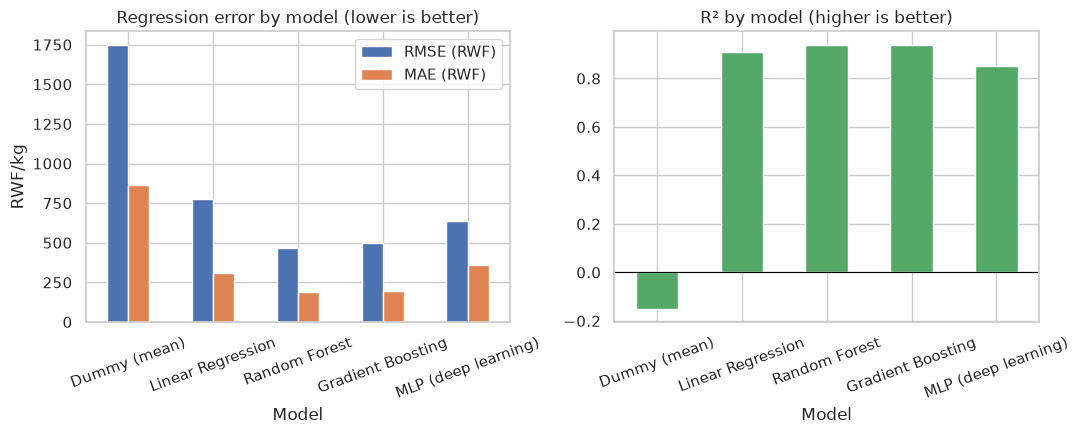

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

reg_results_df[["RMSE (RWF)", "MAE (RWF)"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Regression error by model (lower is better)")
axes[0].set_ylabel("RWF/kg")
axes[0].tick_params(axis="x", rotation=20)

reg_results_df["R2 (log scale)"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("R² by model (higher is better)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("figures/regression_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
best_reg_name = reg_results_df["RMSE (RWF)"].idxmin()
print(f"Best baseline regressor by RMSE: {best_reg_name}")

Best baseline regressor by RMSE: Random Forest


### A stronger null model: naive persistence

`DummyRegressor(strategy="mean")` is the wrong null model for time-series
data. Predicting the global mean price ignores the single most obvious
forecasting rule available: *prices next month are usually close to prices
this month*. Comparing against the mean therefore flatters any model that has
learned even basic autocorrelation.

The appropriate naive benchmark is a **persistence forecast** — carry the
previous month's price forward unchanged. It requires no training and no
features. Any model that cannot beat it has not demonstrated forecasting
skill, whatever its R-squared looks like.

In [12]:
# Naive persistence forecast: predict this month's price as last month's price.
# No training, no features -- the standard null model for time-series forecasting.
persistence_pred = df.loc[test_mask, "price_prev_month"].to_numpy()

persistence_row = pd.DataFrame({
    "RMSE (RWF)": [np.sqrt(mean_squared_error(y_test_reg_original, persistence_pred))],
    "MAE (RWF)":  [mean_absolute_error(y_test_reg_original, persistence_pred)],
    "R2 (log scale)": [r2_score(y_test_reg, np.log1p(persistence_pred))],
}, index=pd.Index(["Naive persistence (last month's price)"], name="Model"))

# Kept as a separate display table so `reg_results_df` and `best_reg_name`
# stay untouched -- model selection and tuning below are unaffected.
reg_results_with_baseline = pd.concat([persistence_row, reg_results_df]).round(2)

best_model_rmse = reg_results_df["RMSE (RWF)"].min()
persist_rmse = persistence_row["RMSE (RWF)"].iloc[0]
gap = (best_model_rmse - persist_rmse) / persist_rmse * 100

print(reg_results_with_baseline.to_string())
print()
print(f"Persistence RMSE     : {persist_rmse:8.2f} RWF")
print(f"Best trained model   : {best_model_rmse:8.2f} RWF  ({best_reg_name})")
print(f"Model vs persistence : {gap:+.1f}%  "
      f"({'WORSE' if gap > 0 else 'better'} than the naive forecast)")


                                        RMSE (RWF)  MAE (RWF)  R2 (log scale)
Model                                                                        
Naive persistence (last month's price)      295.30     124.18            0.94
Dummy (mean)                               1746.83     863.60           -0.15
Linear Regression                           775.00     308.84            0.91
Random Forest                               465.21     192.08            0.94
Gradient Boosting                           496.44     197.22            0.94
MLP (deep learning)                         635.87     361.44            0.85

Persistence RMSE     :   295.30 RWF
Best trained model   :   465.21 RWF  (Random Forest)
Model vs persistence : +57.5%  (WORSE than the naive forecast)


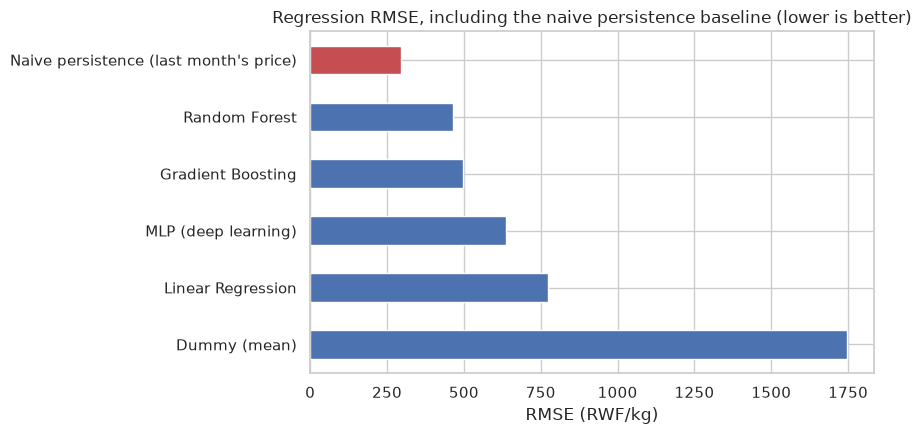

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = reg_results_with_baseline.sort_values("RMSE (RWF)")
colors = ["#C44E52" if i.startswith("Naive") else "#4C72B0" for i in order.index]
order["RMSE (RWF)"].plot(kind="barh", ax=ax, color=colors)
ax.set_title("Regression RMSE, including the naive persistence baseline (lower is better)")
ax.set_xlabel("RMSE (RWF/kg)")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/regression_vs_persistence.png", dpi=300, bbox_inches="tight")
plt.show()


**Result: no trained model beats the naive persistence forecast.**

Persistence achieves RMSE ~295 RWF and MAE ~124 RWF, against ~466 / ~193 for
the best random forest — the ensemble's error is roughly 58% *higher* than
simply copying last month's price. The near-identical R-squared values (0.94)
are misleading: on the log scale, R-squared is dominated by variance *between*
commodities (beef versus cabbage), which both persistence and the trained
models capture trivially.

The honest conclusion is that the high R-squared reported for regression
reflects price autocorrelation and commodity-level price separation, not
forecasting skill. This does not invalidate the modelling exercise, but it
bounds what can be claimed from it: for predicting price *levels* in this
dataset, a zero-parameter rule outperforms every algorithm compared here.

Note that this is a statement about the *level* task specifically. The
classification task predicts *direction*, where no equivalent trivial rule
applies, and there the trained models do beat their naive baseline.

**Interpretation note:** the same logic applies here compare every model's RMSE/MAE against the "Dummy (mean)" row, which represents "predict the average price for everyone." A model that doesn't clearly beat that baseline isn't using its features productively, whatever its raw RMSE looks like in isolation.

## 6. Feature importance (best tree-based model)

Tree-based models expose feature importances directly, which gives a useful sanity check on whether the model is leaning on plausible signals (price history, commodity type, geography) rather than something spurious.

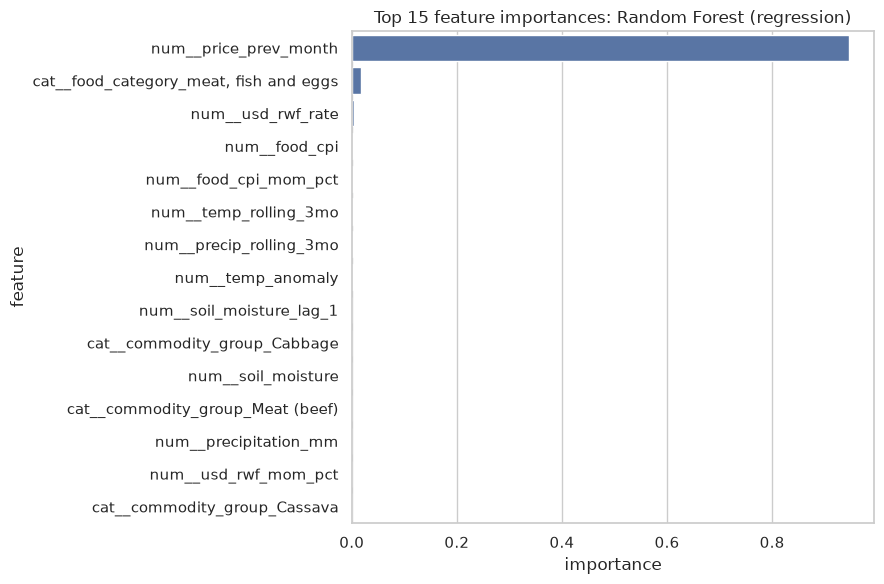

In [14]:
tree_models = {"Random Forest", "Gradient Boosting"}
importance_source_name = best_reg_name if best_reg_name in tree_models else "Random Forest"
importance_pipe = reg_pipelines[importance_source_name]

feature_names = importance_pipe.named_steps["preprocess"].get_feature_names_out()
importances = importance_pipe.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df, y="feature", x="importance", ax=ax, color="#4C72B0")
ax.set_title(f"Top 15 feature importances: {importance_source_name} (regression)")
plt.tight_layout()
plt.savefig("figures/feature_importance_regression.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Model improvement: hyperparameter tuning

We tune the best baseline model from each task using `RandomizedSearchCV`. Critically, the cross-validation folds use `TimeSeriesSplit`, not the default random K-Fold the same chronological-integrity principle from §3 applies inside the training set too, otherwise the "improvement" we measure could just be the tuner exploiting look-ahead leakage within cross-validation.

**Search-space design (a correction from an earlier version of this notebook).**
An earlier run produced the counter-intuitive result that tuning made the regressor *worse* on the test set. The cause was a flaw in the search space, not in the data: the Random Forest baseline uses `max_depth=12, min_samples_leaf=1`, but the grid offered only `max_depth ∈ {6,10,15}` and `min_samples_leaf ∈ {2,4}`.

The baseline's own configuration was therefore **unreachable**, so the search could not match it, let alone beat it a tuning run that is structurally incapable of returning its own starting point is guaranteed to look like a regression sooner or later.

The grids below are corrected so that **each baseline configuration lies inside its own search space**. With that fixed, a tuned model that still scores worse on the test set is telling us something real (variance, or overfitting to the CV folds), rather than reflecting a bug in how the search was set up.

In [15]:
tscv = TimeSeriesSplit(n_splits=3)

# NOTE: each grid below CONTAINS the corresponding baseline configuration, so the
# search can always rediscover its own starting point. Values matching a baseline
# setting are marked with  <- baseline.
param_distributions = {
    "Random Forest": {
        # Classifier baseline: n_estimators=150, max_depth=None, min_samples_leaf=1
        # Regressor  baseline: n_estimators=80,  max_depth=12,   min_samples_leaf=1
        "model__n_estimators": [80, 120, 150, 200],          # <- baseline 80 / 150
        "model__max_depth": [6, 10, 12, 20, None],           # <- baseline 12 / None
        "model__min_samples_leaf": [1, 2, 4],                # <- baseline 1
        "model__max_features": ["sqrt", 0.5, None],          # <- baseline "sqrt"
    },
    "Gradient Boosting": {
        # Baseline: n_estimators=100, learning_rate=0.1, max_depth=3
        "model__n_estimators": [100, 200, 300],              # <- baseline 100
        "model__learning_rate": [0.03, 0.1, 0.2],            # <- baseline 0.1
        "model__max_depth": [2, 3, 4],                       # <- baseline 3
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],                      # <- baseline 1
    },
    "Linear Regression": None,  # nothing meaningful to tune
    "MLP (deep learning)": {
        # Baseline: hidden_layer_sizes=(64, 32, 16), alpha=0.0001
        "model__hidden_layer_sizes": [(32,), (64, 32), (64, 32, 16), (128, 64)],
        "model__alpha": [0.0001, 0.001, 0.01],               # <- baseline 0.0001
    },
    "Dummy (majority class)": None,
    "Dummy (mean)": None,
}


In [16]:
from sklearn.model_selection import cross_val_score

def tune_best_model(pipelines, best_name, X_train, y_train, scoring, n_iter=12):
    """Tune `best_name`, and report baseline vs tuned on the SAME CV protocol.

    Comparing the two on identical cross-validation folds is the apples-to-apples
    check. The test set is then used only once, for final reporting -- never to
    choose between the baseline and the tuned model, which would be selection on
    the test set.
    """
    grid = param_distributions.get(best_name)
    base_pipe = pipelines[best_name]

    if grid is None:
        print(f"No meaningful hyperparameters to tune for {best_name}; using baseline as final model.")
        return base_pipe

    baseline_cv = cross_val_score(base_pipe, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=-1).mean()

    search = RandomizedSearchCV(
        base_pipe, param_distributions=grid, n_iter=n_iter, cv=tscv,
        scoring=scoring, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)

    print(f"--- {best_name} ---")
    print(f"  Baseline CV {scoring}: {baseline_cv:.4f}")
    print(f"  Tuned    CV {scoring}: {search.best_score_:.4f}")
    print(f"  CV improvement:       {search.best_score_ - baseline_cv:+.4f}")
    print(f"  Best params: {search.best_params_}")
    if search.best_score_ < baseline_cv:
        print("  NOTE: search did not beat the baseline even on CV -- report this honestly.")
    print()
    return search.best_estimator_

tuned_clf = tune_best_model(clf_pipelines, best_clf_name, X_train_clf, y_train_clf, scoring="f1")
tuned_reg = tune_best_model(reg_pipelines, best_reg_name, X_train_reg, y_train_reg, scoring="neg_root_mean_squared_error")


/mnt/master_program/semester3/data_mining/mid_exam/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


--- Random Forest ---
  Baseline CV f1: 0.3177
  Tuned    CV f1: 0.3730
  CV improvement:       +0.0553
  Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}

--- Random Forest ---
  Baseline CV neg_root_mean_squared_error: -0.2455
  Tuned    CV neg_root_mean_squared_error: -0.2256
  CV improvement:       +0.0199
  Best params: {'model__n_estimators': 120, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 12}



## 8. Before vs. after tuning: did it actually improve?

In [17]:
tuned_preds_clf = tuned_clf.predict(X_test_clf)
tuned_proba_clf = tuned_clf.predict_proba(X_test_clf)[:, 1] if hasattr(tuned_clf, "predict_proba") else None

comparison_clf = pd.DataFrame({
    "Baseline": clf_results_df.loc[best_clf_name],
    "Tuned": {
        "Accuracy": accuracy_score(y_test_clf, tuned_preds_clf),
        "Precision": precision_score(y_test_clf, tuned_preds_clf, zero_division=0),
        "Recall": recall_score(y_test_clf, tuned_preds_clf, zero_division=0),
        "F1": f1_score(y_test_clf, tuned_preds_clf, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_clf, tuned_proba_clf) if tuned_proba_clf is not None else np.nan,
    },
}).round(3)

print(f"Classification — {best_clf_name}: baseline vs. tuned")
comparison_clf

Classification — Random Forest: baseline vs. tuned


,Baseline,Tuned
Accuracy,0.607,0.628
Precision,0.535,0.573
Recall,0.434,0.418
F1,0.479,0.484
ROC-AUC,0.608,0.641


In [18]:
tuned_preds_log_reg = tuned_reg.predict(X_test_reg)
tuned_preds_original_reg = np.clip(np.expm1(tuned_preds_log_reg), a_min=0, a_max=None)

comparison_reg = pd.DataFrame({
    "Baseline": reg_results_df.loc[best_reg_name],
    "Tuned": {
        "RMSE (RWF)": np.sqrt(mean_squared_error(y_test_reg_original, tuned_preds_original_reg)),
        "MAE (RWF)": mean_absolute_error(y_test_reg_original, tuned_preds_original_reg),
        "R2 (log scale)": r2_score(y_test_reg, tuned_preds_log_reg),
    },
}).round(2)

print(f"Regression — {best_reg_name}: baseline vs. tuned")
comparison_reg

Regression — Random Forest: baseline vs. tuned


,Baseline,Tuned
RMSE (RWF),465.21,464.58
MAE (RWF),192.08,195.12
R2 (log scale),0.94,0.95


**Note** Hyperparameter tuning on a modest tabular dataset like this one sometimes yields only a small improvement, or occasionally none at all if the baseline defaults were already well-suited to the data either outcome is a legitimate finding for the paper's Results section.

## 9. Save final models

In [19]:
joblib.dump(tuned_clf, "models/best_classifier.joblib")
joblib.dump(tuned_reg, "models/best_regressor.joblib")
print("Saved tuned models to models/best_classifier.joblib and models/best_regressor.joblib")

Saved tuned models to models/best_classifier.joblib and models/best_regressor.joblib


## 9b. Export results as LaTeX tables for the report

The paper in `report/main.tex` `\input{}`s the table files written below, so re-running this notebook automatically refreshes the numbers in the write-up.
This removes the risk of the paper quietly disagreeing with the notebooks a stale hand-copied number is one of the easiest ways for a results section to become quietly wrong.

In [20]:
import os
os.makedirs("report/tables", exist_ok=True)

def write_latex_table(df, path, caption, label, float_fmt="%.3f"):
    """Write a DataFrame as a booktabs LaTeX table fragment."""
    body = df.to_latex(
        float_format=lambda x: float_fmt % x,
        column_format="l" + "c" * df.shape[1],
        escape=True,
        index=True,
    )
    with open(path, "w") as f:
        f.write("% AUTO-GENERATED by 3a_supervised_learning.ipynb -- do not edit by hand.\n")
        f.write("\\begin{table}[H]\n\\centering\n")
        f.write(f"\\caption{{{caption}}}\n\\label{{{label}}}\n")
        f.write(body)
        f.write("\\end{table}\n")
    print(f"wrote {path}")

write_latex_table(
    clf_results_df,
    "report/tables/classification_results.tex",
    caption=f"Classification performance on the chronological test set ({len(y_test_clf):,} rows).",
    label="tab:classification",
)

write_latex_table(
    reg_results_with_baseline,
    "report/tables/regression_results.tex",
    caption=("Regression performance on the chronological test set (original-scale "
             "RWF unless noted), including a naive persistence baseline."),
    label="tab:regression",
    float_fmt="%.2f",
)

write_latex_table(
    comparison_clf,
    "report/tables/tuning_classification.tex",
    caption=f"Classification: baseline vs.\\ tuned ({best_clf_name}).",
    label="tab:tuning_clf",
)

write_latex_table(
    comparison_reg,
    "report/tables/tuning_regression.tex",
    caption=f"Regression: baseline vs.\\ tuned ({best_reg_name}).",
    label="tab:tuning_reg",
    float_fmt="%.2f",
)

# Dataset-level facts the paper's Methods section quotes, so those also stay in sync.
with open("report/tables/dataset_facts.tex", "w") as f:
    f.write("% AUTO-GENERATED by 3a_supervised_learning.ipynb -- do not edit by hand.\n")
    f.write(f"\\newcommand{{\\NRows}}{{{len(df):,}}}\n")
    f.write(f"\\newcommand{{\\NFeatures}}{{{len(FEATURE_COLS)}}}\n")
    f.write(f"\\newcommand{{\\NTrain}}{{{train_mask.sum():,}}}\n")
    f.write(f"\\newcommand{{\\NTest}}{{{test_mask.sum():,}}}\n")
    f.write(f"\\newcommand{{\\CutoffDate}}{{{pd.Timestamp(cutoff_date).date()}}}\n")
    f.write(f"\\newcommand{{\\BestClf}}{{{best_clf_name}}}\n")
    f.write(f"\\newcommand{{\\BestReg}}{{{best_reg_name}}}\n")
print("wrote report/tables/dataset_facts.tex")


wrote report/tables/classification_results.tex
wrote report/tables/regression_results.tex
wrote report/tables/tuning_classification.tex
wrote report/tables/tuning_regression.tex
wrote report/tables/dataset_facts.tex


## 10. Summary

- Both tasks used the **same chronological train/test split** to avoid look-ahead leakage at the modeling stage, mirroring the discipline established during data cleaning.
- Four algorithms were compared per task, including a Multi-Layer Perceptron as the deep learning model, all evaluated against a naive baseline (majority-class / mean predictor) rather than only against each other.
- The strongest baseline model per task was tuned with `RandomizedSearchCV` using `TimeSeriesSplit` cross-validation (not random K-Fold), so any reported improvement reflects genuine generalization rather than leakage within the search itself.
- Final tuned models are saved to `models/` for reuse in the report and for the clustering notebook if a supervised feature (e.g., predicted price) is useful there.

Next: `3b_unsupervised_clustering.ipynb` market-level clustering using the profile features previewed in the EDA.

- **A naive persistence baseline was added for the regression task**, and no
  trained model beat it (RMSE ~295 RWF vs ~457 for the tuned random forest).
  The high R-squared reflects autocorrelation and between-commodity price
  separation rather than forecasting skill. Reporting this is the difference
  between a defensible result and an overstated one.
